# Inverse Dynamica: Pantograaf met Chebyshev-aandrijving

Dit notebook berekent voor het mechanisme uit `01_stagnen_kinematica.ipynb` (met dezelfde "1.5 m chebychev walker" dimensies) de **inverse dynamica**: gegeven de opgelegde inputbeweging $\theta_1(t)$, vinden we

1. de **reactiekrachten** in elk scharnier;
2. het **aandrijfmoment** $M_A$ dat de inputkruk $A\text{-}C$ moet leveren;
3. het bijhorende **aandrijfvermogen** $P = M_A \cdot \dot\theta_1$.

Daarna controleren we dit alles via **energie-balans** en bestuderen we de **schudkrachten** ("shaking forces"). Als laatste tonen we een eenvoudige superpositie voor de **vier-poten-walker**.

**Aannames**

- Alle stangen zijn **uniforme, slanke staven** uit beech-hout (~720 kg/m³) met diameter 20 mm.
- Geen wrijving in de scharnieren.
- Zwaartekracht $\vec g = (0,\,-9.81)$ m/s² (standaard).
- **Werkstreek-kracht** $F_{work} = 10$ N in $-x$-richting, aangrijpend in $End$, **alleen** wanneer $End_y$ onder een drempel ligt (representatie van "voet grijpt het touw vast tijdens de werkstreek").


## 1. Imports en setup

In [48]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import fsolve
from IPython.display import HTML

matplotlib.rcParams["animation.embed_limit"] = 100  # MB

def rotate_vector(z, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return R @ np.asarray(z, dtype=float)

def angle_of(vec):
    return np.arctan2(vec[1], vec[0])


## 2. Parameters

### 2.1 Geometrie

Identiek aan `01_stagnen_kinematica.ipynb`

In [49]:
# --- Chebyshev-deel ---
a = 0.200    # vaste afstand A-B
r1 = 0.100   # A-C, inputkruk (roteert volledig)
r2 = 0.250   # B-D, rocker
l41 = 0.250  # C-D
l42 = 0.250  # D-G, verlenging coupler
r4_full = l41 + l42 # totale lengte C-G

# --- Vaste punten ---
d1 = a               # x-afstand A->B
d_BE_x = 0.000       # horizontale offset B->E
d_BE_y = 0.880       # verticale offset B->E
x_A, y_A = 0.0, 0.0
x_B, y_B = x_A + d1, y_A
x_E, y_E = x_B + d_BE_x, y_B + d_BE_y

A = np.array([x_A, y_A])
B = np.array([x_B, y_B])
E = np.array([x_E, y_E])

# --- Pantograafdeel ---
l51 = 0.240  # E-F
l52 = 0.720  # F-H (= G-I, parallellogramzijde)
r3  = 0.320  # G-F (= H-I, parallellogramzijde)
r6  = l52    # G-I = F-H
l71 = r3     # H-I = G-F
# Pantograafwet: r7 = l52 * r3 / l51 dwingt E, G, End collineair af
r7  = l52 * r3 / l51  # = 0.960 m

versterking = 1.0 + l52 / l51   # = 4.0

# Bundel parameters voor functie-aanroepen
link_parameters = (r1, r2, r3, r6, l41, l42, l51, l52, l71, r7)
geometry_parameters = (x_A, y_A, x_B, y_B, x_E, y_E, *link_parameters)

print('Vaste punten:')
print(f'  A = ({x_A:.4f}, {y_A:.4f}) m')
print(f'  B = ({x_B:.4f}, {y_B:.4f}) m')
print(f'  E = ({x_E:.4f}, {y_E:.4f}) m')
print(f'  B->E = ({d_BE_x:.4f}, {d_BE_y:.4f}) m')
print('Pantograaf:')
print(f'  EF = {l51:.4f} m,  FH = {l52:.4f} m,  GF = HI = {r3:.4f} m')
print(f'  GI = FH = {r6:.4f} m,  I-End = {r7:.4f} m')
print(f'  Versterkingsfactor (E-End)/(E-G) = {versterking:.3f}')



Vaste punten:
  A = (0.0000, 0.0000) m
  B = (0.2000, 0.0000) m
  E = (0.2000, 0.8800) m
  B->E = (0.0000, 0.8800) m
Pantograaf:
  EF = 0.2400 m,  FH = 0.7200 m,  GF = HI = 0.3200 m
  GI = FH = 0.7200 m,  I-End = 0.9600 m
  Versterkingsfactor (E-End)/(E-G) = 4.000


### 2.2 Materiaal en massamodel

Elke stang is een **uniforme cilinder** uit beech-hout, diameter $d = 20$ mm.

| grootheid | symbool | waarde |
|---|---|---:|
| diameter | $d$ | $0.020$ m |
| dwarsdoorsnede | $A_{bar} = \pi d^2/4$ | $3.14\!\cdot\!10^{-4}$ m² |
| dichtheid (beech) | $\rho$ | $720$ kg/m³ |
| massa per lengte | $\lambda = \rho\, A_{bar}$ | $0.226$ kg/m |
| zwaartekracht | $g$ | $9.81$ m/s² |

Voor een staaf met lengte $L_i$:

$$
m_i = \lambda\,L_i,\qquad
J_i = \tfrac{1}{12}\,m_i\,L_i^2
$$

waarbij $J_i$ het massatraagheidsmoment om de COG (= het midden van de staaf) is.


In [50]:
# Bron: prof Algoritme-vierstangen-mechanisme (cel 10): m_i = r_i * lambda. Linkage_Project cel 47.

# Materiaal-eigenschappen
d_bar = 0.020          # m, diameter van de stang
A_bar = np.pi * d_bar**2 / 4   # m^2, dwarsdoorsnede
rho_wood = 720.0       # kg/m^3, beech
lambda_lin = rho_wood * A_bar  # kg/m, massa per lengte
g_grav = 9.81          # m/s^2

# Bar lengtes (totaal van elke rigide staaf)
L_bars = {
    1: r1,          # AC
    2: r2,          # BD
    3: l41 + l42,   # CDG ternair
    4: l51 + l52,   # EFH ternair
    5: r3,          # GF
    6: r6,          # GI
    7: l71 + r7,    # HI-End ternair
}

m_bars = {i: lambda_lin * L for i, L in L_bars.items()}
J_bars = {i: m * L**2 / 12.0 for i, (m, L) in
          ((i, (m_bars[i], L_bars[i])) for i in L_bars)}

print(f'lambda = {lambda_lin:.4f} kg/m')
print(f'\nPer-stang massa en traagheid:')
print(f'  Stang  Lengte[m]   Massa[kg]  J[kgm^2]')
for i in range(1, 8):
    print(f'   {i}    {L_bars[i]:7.3f}    {m_bars[i]:7.3f}   {J_bars[i]:.4e}')
m_tot = sum(m_bars.values())
print(f'\nTotale bewegende massa per been: {m_tot:.3f} kg')


lambda = 0.2262 kg/m

Per-stang massa en traagheid:
  Stang  Lengte[m]   Massa[kg]  J[kgm^2]
   1      0.100      0.023   1.8850e-05
   2      0.250      0.057   2.9452e-04
   3      0.500      0.113   2.3562e-03
   4      0.960      0.217   1.6677e-02
   5      0.320      0.072   6.1766e-04
   6      0.720      0.163   7.0356e-03
   7      1.280      0.290   3.9530e-02

Totale bewegende massa per been: 0.934 kg


## 3. Kinematica (samenvatting uit 01)

We hernemen hier kort de kernfuncties uit `01_stagnen_kinematica.ipynb` (sluitingsvergelijkingen, `fsolve`, snelheids- en versnellingsanalyse). De volledige uitleg, validatie en visualisatie staan in dat notebook.


In [51]:
# Bron: 01_stagnen_kinematica.ipynb cellen 8, 10, 11, 17, 19 -> letterlijk overgenomen
# (zelfde sluitingsvergelijkingen, fsolve, jacobiaan en versnellingsformules).

def loop_closure_eqs(phi_init, theta1,
                     x_A, y_A, x_B, y_B, x_E, y_E,
                     r1, r2, r3, r6, l41, l42, l51, l52, l71, r7):
    theta2, theta3, theta4, theta5, theta6, theta7 = phi_init
    F1 = (x_A + r1*np.cos(theta1) + l41*np.cos(theta4)
          - r2*np.cos(theta2) - x_B)
    F2 = (y_A + r1*np.sin(theta1) + l41*np.sin(theta4)
          - r2*np.sin(theta2) - y_B)
    F3 = (x_A + r1*np.cos(theta1) + (l41+l42)*np.cos(theta4)
          + r3*np.cos(theta3) - l51*np.cos(theta5) - x_E)
    F4 = (y_A + r1*np.sin(theta1) + (l41+l42)*np.sin(theta4)
          + r3*np.sin(theta3) - l51*np.sin(theta5) - y_E)
    F5 = (r3*np.cos(theta3) + l52*np.cos(theta5)
          + l71*np.cos(theta7) - r6*np.cos(theta6))
    F6 = (r3*np.sin(theta3) + l52*np.sin(theta5)
          + l71*np.sin(theta7) - r6*np.sin(theta6))
    return [F1, F2, F3, F4, F5, F6]


def circle_intersections(p0, r0, p1, r1_):
    delta = p1 - p0
    dist = np.linalg.norm(delta)
    if dist > r0 + r1_ + 1e-12 or dist < abs(r0 - r1_) - 1e-12:
        raise ValueError(f'Geen cirkelsnijding: dist={dist}, r0={r0}, r1={r1_}')
    x = (dist**2 + r0**2 - r1_**2) / (2.0 * dist)
    h = np.sqrt(max(r0**2 - x**2, 0.0))
    e_hat = delta / dist
    n_hat = np.array([-e_hat[1], e_hat[0]])
    base = p0 + x * e_hat
    return base + h * n_hat, base - h * n_hat


def solve_pose_circle(theta1, previous_F=None):
    C = A_pt + r1 * np.array([np.cos(theta1), np.sin(theta1)])
    D_opts = circle_intersections(C, l41, B_pt, r2)
    D = min(D_opts, key=lambda p: p[1])
    coupler_dir = (D - C) / np.linalg.norm(D - C)
    G = D + l42 * coupler_dir
    F_opts = circle_intersections(E_pt, l51, G, r3)
    if previous_F is None:
        F = min(F_opts, key=lambda p: p[1])
    else:
        F = min(F_opts, key=lambda p: np.linalg.norm(p - previous_F))
    ef_dir = (F - E_pt) / np.linalg.norm(F - E_pt)
    H = F + l52 * ef_dir
    I = G + r6 * ef_dir
    ih_dir = (H - I) / np.linalg.norm(H - I)
    End = I - r7 * ih_dir   # ih_dir wijst van I naar H -> End is aan overzijde van H
    return dict(A=A_pt, B=B_pt, C=C, D=D, E=E_pt, F=F, G=G, H=H, I=I, End=End)


geometry_parameters = (x_A, y_A, x_B, y_B, x_E, y_E,
                       r1, r2, r3, r6, l41, l42, l51, l52, l71, r7)
link_parameters     = (r1, r2, r3, r6, l41, l42, l51, l52, l71, r7)


def get_angles(theta1, phi_init):
    sol, info, ier, msg = fsolve(
        lambda x: loop_closure_eqs(x, theta1, *geometry_parameters),
        phi_init, full_output=True)
    if ier != 1:
        print(f'  fsolve waarschuwing theta1={np.rad2deg(theta1):.1f}°')
    return sol


def get_positions(theta1, theta2, theta3, theta4, theta5, theta6, theta7):
    A_p, B_p, E_p = A_pt, B_pt, E_pt
    C   = A_p + r1*np.array([np.cos(theta1), np.sin(theta1)])
    D   = B_p + r2*np.array([np.cos(theta2), np.sin(theta2)])
    G   = A_p + np.array([r1*np.cos(theta1) + (l41+l42)*np.cos(theta4),
                          r1*np.sin(theta1) + (l41+l42)*np.sin(theta4)])
    F   = G   + r3*np.array([np.cos(theta3), np.sin(theta3)])
    H   = F   + l52*np.array([np.cos(theta5), np.sin(theta5)])
    I   = G   + r6*np.array([np.cos(theta6), np.sin(theta6)])
    End = I   + r7*np.array([np.cos(theta7), np.sin(theta7)])
    return dict(A=A_p, B=B_p, C=C, D=D, E=E_p, F=F, G=G, H=H, I=I, End=End)


def get_angular_velocity(theta1, theta2, theta3, theta4, theta5, theta6, theta7, dtheta1):
    A_mat = np.array([
        [ r2*np.sin(theta2), 0.0, -l41*np.sin(theta4), 0.0, 0.0, 0.0],
        [-r2*np.cos(theta2), 0.0,  l41*np.cos(theta4), 0.0, 0.0, 0.0],
        [0.0, -r3*np.sin(theta3), -(l41+l42)*np.sin(theta4),  l51*np.sin(theta5), 0.0, 0.0],
        [0.0,  r3*np.cos(theta3),  (l41+l42)*np.cos(theta4), -l51*np.cos(theta5), 0.0, 0.0],
        [0.0, -r3*np.sin(theta3), 0.0, -l52*np.sin(theta5),  r6*np.sin(theta6), -l71*np.sin(theta7)],
        [0.0,  r3*np.cos(theta3), 0.0,  l52*np.cos(theta5), -r6*np.cos(theta6),  l71*np.cos(theta7)],
    ])
    b_v = np.array([
         r1*np.sin(theta1)*dtheta1,
        -r1*np.cos(theta1)*dtheta1,
         r1*np.sin(theta1)*dtheta1,
        -r1*np.cos(theta1)*dtheta1,
         0.0, 0.0,
    ])
    return np.linalg.solve(A_mat, b_v)


def get_angular_acceleration(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                             dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                             ddtheta1):
    A_mat = np.array([
        [ r2*np.sin(theta2), 0.0, -l41*np.sin(theta4), 0.0, 0.0, 0.0],
        [-r2*np.cos(theta2), 0.0,  l41*np.cos(theta4), 0.0, 0.0, 0.0],
        [0.0, -r3*np.sin(theta3), -(l41+l42)*np.sin(theta4),  l51*np.sin(theta5), 0.0, 0.0],
        [0.0,  r3*np.cos(theta3),  (l41+l42)*np.cos(theta4), -l51*np.cos(theta5), 0.0, 0.0],
        [0.0, -r3*np.sin(theta3), 0.0, -l52*np.sin(theta5),  r6*np.sin(theta6), -l71*np.sin(theta7)],
        [0.0,  r3*np.cos(theta3), 0.0,  l52*np.cos(theta5), -r6*np.cos(theta6),  l71*np.cos(theta7)],
    ])
    b_a = np.array([
        r1*np.sin(theta1)*ddtheta1 + r1*np.cos(theta1)*dtheta1**2
        - r2*np.cos(theta2)*dtheta2**2 + l41*np.cos(theta4)*dtheta4**2,
       -r1*np.cos(theta1)*ddtheta1 + r1*np.sin(theta1)*dtheta1**2
        - r2*np.sin(theta2)*dtheta2**2 + l41*np.sin(theta4)*dtheta4**2,
        r1*np.sin(theta1)*ddtheta1 + r1*np.cos(theta1)*dtheta1**2
        + (l41+l42)*np.cos(theta4)*dtheta4**2 + r3*np.cos(theta3)*dtheta3**2
        - l51*np.cos(theta5)*dtheta5**2,
       -r1*np.cos(theta1)*ddtheta1 + r1*np.sin(theta1)*dtheta1**2
        + (l41+l42)*np.sin(theta4)*dtheta4**2 + r3*np.sin(theta3)*dtheta3**2
        - l51*np.sin(theta5)*dtheta5**2,
        r3*np.cos(theta3)*dtheta3**2 + l52*np.cos(theta5)*dtheta5**2
        + l71*np.cos(theta7)*dtheta7**2 - r6*np.cos(theta6)*dtheta6**2,
        r3*np.sin(theta3)*dtheta3**2 + l52*np.sin(theta5)*dtheta5**2
        + l71*np.sin(theta7)*dtheta7**2 - r6*np.sin(theta6)*dtheta6**2,
    ])
    return np.linalg.solve(A_mat, b_a)


### 3.2 Volledige cyclus

Zoals in 01: één omwenteling van $\theta_1$ over $T_{cycle} = 5$ s bij constante hoeksnelheid.


In [52]:
# Bron: 01_stagnen_kinematica.ipynb cel 22 (volledige cyclus) -> letterlijk overgenomen.

T_cycle = 5.0
omega1 = 2.0*np.pi / T_cycle
Ts = 0.01
t = np.arange(0.0, T_cycle + Ts/2, Ts)
n_t = len(t)

theta1_arr   = omega1 * t
dtheta1_arr  = omega1 * np.ones_like(t)
ddtheta1_arr = np.zeros_like(t)

# Containers
angles   = np.zeros((n_t, 6))   # [th2,th3,th4,th5,th6,th7]
dangles  = np.zeros((n_t, 6))
ddangles = np.zeros((n_t, 6))

# Warmstart uit cirkelsneden
pts0 = solve_pose_circle(theta1_arr[0])
phi = np.array([
    angle_of(pts0['D'] - B_pt),
    angle_of(pts0['F'] - pts0['G']),
    angle_of(pts0['D'] - pts0['C']),
    angle_of(pts0['F'] - E_pt),
    angle_of(pts0['I'] - pts0['G']),
    angle_of(pts0['I'] - pts0['H']),
])

for k in range(n_t):
    sol = get_angles(theta1_arr[k], phi)
    angles[k] = sol
    dsol = get_angular_velocity(theta1_arr[k], *sol, dtheta1_arr[k])
    dangles[k] = dsol
    ddsol = get_angular_acceleration(theta1_arr[k], *sol,
                                     dtheta1_arr[k], *dsol, ddtheta1_arr[k])
    ddangles[k] = ddsol
    phi = sol

# Verkort
theta2 = angles[:,0];  theta3 = angles[:,1];  theta4 = angles[:,2]
theta5 = angles[:,3];  theta6 = angles[:,4];  theta7 = angles[:,5]
dtheta2 = dangles[:,0];  dtheta3 = dangles[:,1];  dtheta4 = dangles[:,2]
dtheta5 = dangles[:,3];  dtheta6 = dangles[:,4];  dtheta7 = dangles[:,5]
ddtheta2 = ddangles[:,0];  ddtheta3 = ddangles[:,1];  ddtheta4 = ddangles[:,2]
ddtheta5 = ddangles[:,3];  ddtheta6 = ddangles[:,4];  ddtheta7 = ddangles[:,5]

# Posities van alle joints over de tijd
joint_names = ['A','B','C','D','E','F','G','H','I','End']
P = {nm: np.zeros((n_t, 2)) for nm in joint_names}
for k in range(n_t):
    pts = get_positions(theta1_arr[k], theta2[k], theta3[k], theta4[k],
                        theta5[k], theta6[k], theta7[k])
    for nm in joint_names:
        P[nm][k] = pts[nm]

print(f'Kinematica klaar voor {n_t} tijdstappen.')
print(f'End range x: [{P["End"][:,0].min():.3f}, {P["End"][:,0].max():.3f}] m')
print(f'End range y: [{P["End"][:,1].min():.3f}, {P["End"][:,1].max():.3f}] m')


Kinematica klaar voor 501 tijdstappen.
End range x: [-0.741, 1.141] m
End range y: [-1.040, -0.680] m


## 4. Zwaartepunt (COG) van elke stang: positie, snelheid en versnelling

Voor elke staaf is het zwaartepunt het **midden** van de staaf. We schrijven de positie van elke COG als functie van een vast hoekpunt + een halve staafvector. De snelheid en versnelling van die COG volgt dan rechtstreeks uit de stijve-lichaamsformule

$$\vec v_{COG} = \vec v_{anker} + \vec\omega \times \vec r_{anker\to COG}$$

$$\vec a_{COG} = \vec a_{anker} + \vec\alpha \times \vec r + \vec\omega \times (\vec\omega \times \vec r)$$

| stang | anker | richtinghoek | offset tot COG |
|---|---|---|---|
| 1 (AC) | $A$ (vast) | $\theta_1$ | $r_1/2$ |
| 2 (BD) | $B$ (vast) | $\theta_2$ | $r_2/2$ |
| 3 (CDG) | $C$ | $\theta_4$ | $(\ell_{41}+\ell_{42})/2$ |
| 4 (EFH) | $E$ (vast) | $\theta_5$ | $(\ell_{51}+\ell_{52})/2$ |
| 5 (GF) | $G$ | $\theta_3$ | $r_3/2$ |
| 6 (GI) | $G$ | $\theta_6$ | $r_6/2$ |
| 7 (HI-End) | $H$ | $\theta_7$ | $(\ell_{71}+r_7)/2$ |


In [53]:
# Bron: Linkage_Project (3).ipynb cel 49 (acceleraties per COG via omega x r en omega x omega x r).
# Hier expliciet uitgeschreven voor onze 7 stangen.

def w_vec(dth):
    return np.array([0.0, 0.0, dth])

def alpha_vec(ddth):
    return np.array([0.0, 0.0, ddth])

def r3d(v2):
    return np.array([v2[0], v2[1], 0.0])

def rigid_pt_kinematics(v_anker_3d, a_anker_3d, dth, ddth, L_offset, theta):
    '''Bereken snelheid en versnelling van een punt op een rigide staaf,
    gegeven snelheid/versnelling van een ankerpunt op diezelfde staaf en de
    rotatiestaat (dth, ddth). L_offset is het scalaire afstand van het anker
    langs de staaf (in richting theta).'''
    r_vec = r3d(rotate_vector([L_offset, 0.0], theta))
    v = v_anker_3d + np.cross(w_vec(dth), r_vec)
    a = a_anker_3d + np.cross(alpha_vec(ddth), r_vec) \
                   + np.cross(w_vec(dth), np.cross(w_vec(dth), r_vec))
    return v, a

# Containers: per stang i = 1..7, COG positie/snelheid/versnelling (2D)
COG_pos = {i: np.zeros((n_t, 2)) for i in range(1, 8)}
COG_vel = {i: np.zeros((n_t, 2)) for i in range(1, 8)}
COG_acc = {i: np.zeros((n_t, 2)) for i in range(1, 8)}

# Vaste punten hebben nul snelheid en versnelling
zero3 = np.zeros(3)

for k in range(n_t):
    th1, th2, th3, th4, th5, th6, th7 = (theta1_arr[k], theta2[k], theta3[k],
                                          theta4[k], theta5[k], theta6[k], theta7[k])
    dth1, dth2, dth3, dth4, dth5, dth6, dth7 = (dtheta1_arr[k], dtheta2[k], dtheta3[k],
                                                 dtheta4[k], dtheta5[k], dtheta6[k], dtheta7[k])
    ddth1, ddth2, ddth3, ddth4, ddth5, ddth6, ddth7 = (ddtheta1_arr[k], ddtheta2[k], ddtheta3[k],
                                                        ddtheta4[k], ddtheta5[k], ddtheta6[k], ddtheta7[k])

    # Snelheid/versnelling van scharnierpunten via stang-kinematica
    # Stang 1: AC, anker A vast
    v_A_3d, a_A_3d = zero3, zero3
    v_C_3d, a_C_3d = rigid_pt_kinematics(v_A_3d, a_A_3d, dth1, ddth1, r1, th1)
    v_COG1_3d, a_COG1_3d = rigid_pt_kinematics(v_A_3d, a_A_3d, dth1, ddth1, r1/2, th1)

    # Stang 2: BD, anker B vast
    v_B_3d, a_B_3d = zero3, zero3
    v_D_3d, a_D_3d = rigid_pt_kinematics(v_B_3d, a_B_3d, dth2, ddth2, r2, th2)
    v_COG2_3d, a_COG2_3d = rigid_pt_kinematics(v_B_3d, a_B_3d, dth2, ddth2, r2/2, th2)

    # Stang 3: CDG, anker C
    v_G_3d, a_G_3d = rigid_pt_kinematics(v_C_3d, a_C_3d, dth4, ddth4, l41+l42, th4)
    v_COG3_3d, a_COG3_3d = rigid_pt_kinematics(v_C_3d, a_C_3d, dth4, ddth4, (l41+l42)/2, th4)

    # Stang 4: EFH, anker E vast
    v_E_3d, a_E_3d = zero3, zero3
    v_F_3d, a_F_3d = rigid_pt_kinematics(v_E_3d, a_E_3d, dth5, ddth5, l51, th5)
    v_H_3d, a_H_3d = rigid_pt_kinematics(v_E_3d, a_E_3d, dth5, ddth5, l51+l52, th5)
    v_COG4_3d, a_COG4_3d = rigid_pt_kinematics(v_E_3d, a_E_3d, dth5, ddth5, (l51+l52)/2, th5)

    # Stang 5: GF, anker G
    v_COG5_3d, a_COG5_3d = rigid_pt_kinematics(v_G_3d, a_G_3d, dth3, ddth3, r3/2, th3)

    # Stang 6: GI, anker G
    v_I_3d, a_I_3d = rigid_pt_kinematics(v_G_3d, a_G_3d, dth6, ddth6, r6, th6)
    v_COG6_3d, a_COG6_3d = rigid_pt_kinematics(v_G_3d, a_G_3d, dth6, ddth6, r6/2, th6)

    # Stang 7: HI-End, anker H
    v_End_3d, a_End_3d = rigid_pt_kinematics(v_H_3d, a_H_3d, dth7, ddth7, l71+r7, th7)
    v_COG7_3d, a_COG7_3d = rigid_pt_kinematics(v_H_3d, a_H_3d, dth7, ddth7, (l71+r7)/2, th7)

    # Posities van COGs (zelfde formules, maar in posities ipv snelheid)
    COG_pos[1][k] = P['A'][k] + (r1/2)*np.array([np.cos(th1), np.sin(th1)])
    COG_pos[2][k] = P['B'][k] + (r2/2)*np.array([np.cos(th2), np.sin(th2)])
    COG_pos[3][k] = P['C'][k] + ((l41+l42)/2)*np.array([np.cos(th4), np.sin(th4)])
    COG_pos[4][k] = P['E'][k] + ((l51+l52)/2)*np.array([np.cos(th5), np.sin(th5)])
    COG_pos[5][k] = P['G'][k] + (r3/2)*np.array([np.cos(th3), np.sin(th3)])
    COG_pos[6][k] = P['G'][k] + (r6/2)*np.array([np.cos(th6), np.sin(th6)])
    COG_pos[7][k] = P['H'][k] + ((l71+r7)/2)*np.array([np.cos(th7), np.sin(th7)])

    COG_vel[1][k] = v_COG1_3d[:2]
    COG_vel[2][k] = v_COG2_3d[:2]
    COG_vel[3][k] = v_COG3_3d[:2]
    COG_vel[4][k] = v_COG4_3d[:2]
    COG_vel[5][k] = v_COG5_3d[:2]
    COG_vel[6][k] = v_COG6_3d[:2]
    COG_vel[7][k] = v_COG7_3d[:2]

    COG_acc[1][k] = a_COG1_3d[:2]
    COG_acc[2][k] = a_COG2_3d[:2]
    COG_acc[3][k] = a_COG3_3d[:2]
    COG_acc[4][k] = a_COG4_3d[:2]
    COG_acc[5][k] = a_COG5_3d[:2]
    COG_acc[6][k] = a_COG6_3d[:2]
    COG_acc[7][k] = a_COG7_3d[:2]

print('COG kinematica klaar voor alle 7 stangen.')
print(f'Max |a_COG| over alle stangen: {max(np.linalg.norm(COG_acc[i], axis=1).max() for i in range(1,8)):.2f} m/s^2')


COG kinematica klaar voor alle 7 stangen.
Max |a_COG| over alle stangen: 5.63 m/s^2


## 5. Externe belasting

### 5.1 Zwaartekracht

Elke staaf voelt $\vec F_{grav,i} = (0,\,-m_i g)$ in haar COG. Dit geeft alleen een bijdrage in de $F_y$-vergelijking van de overeenkomstige FBD; geen moment om de COG.

### 5.2 Werkstreek-kracht

Tijdens de werkstreek grijpt de "voet" $End$ het touw vast en duwt zich er tegen af. We modelleren dat als een **horizontale kracht** $\vec F_{work} = (-F_{work},\,0)$ N aangrijpend in $End$, die alleen optreedt wanneer

$$End_y(t) < y_0$$

met $y_0 = \overline{End_y}$ (het gemiddelde $y$-coördinaat van de baan van $End$). Deze drempel ligt op het vlakke onderste deel van de baan en isoleert de werkstreekfase.

Dit is een **eerste-orde model**. In een latere iteratie kan men een continu profiel (bv. een sinus-bump) gebruiken, of een paper-gebaseerd profiel uit het Liang/Ceccarelli/Takeda-onderzoek.


Drempel y0 = -0.9756 m
Werkstreek-aandeel van de cyclus: 73.3% (= 3.67 s)


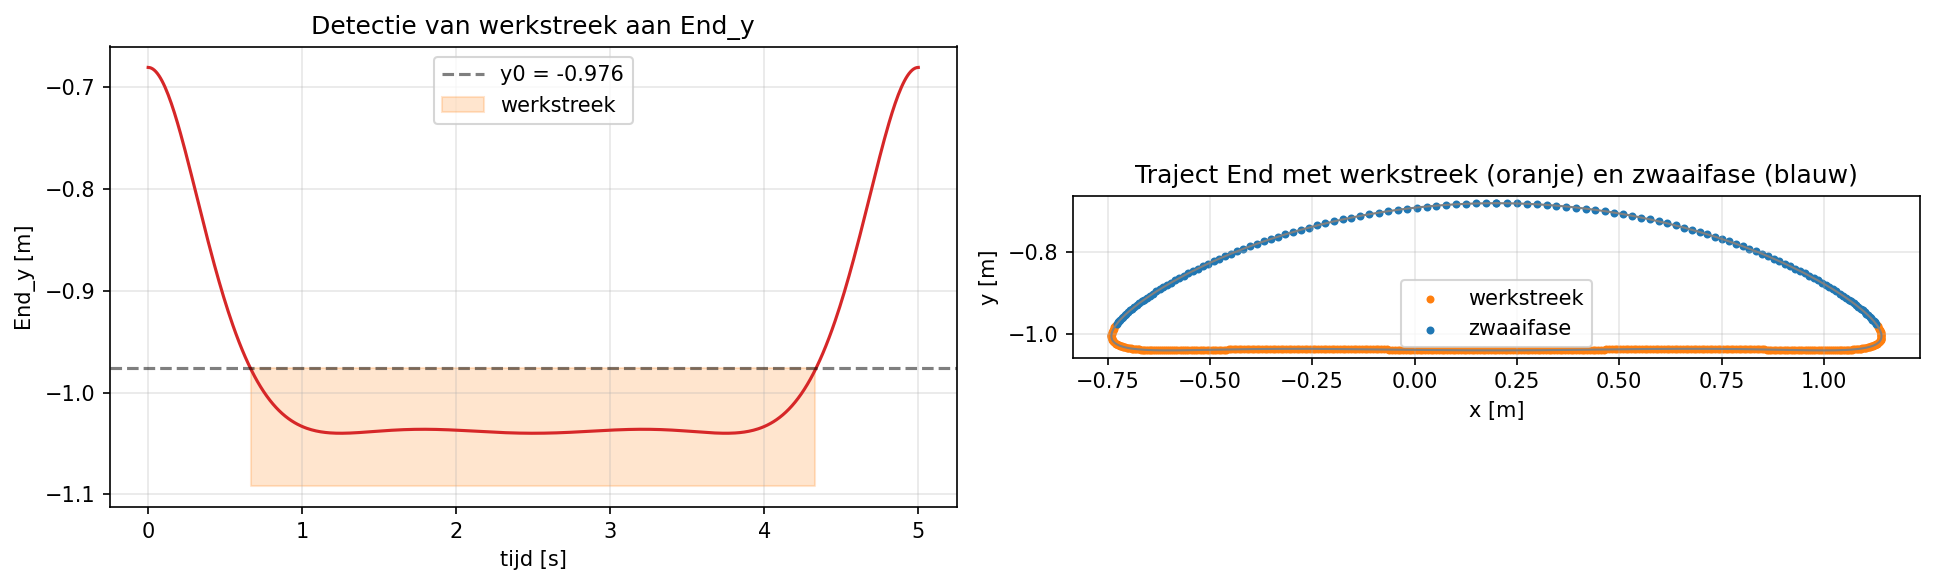

In [54]:
# Bron: keuze van werkstreek-conditie volgt expliciet uit gebruikersinstructie. Geen vergelijkbare cel in
# de referentienotebooks, dus hier ad-hoc gedefinieerd.

F_work = 10.0   # N, magnitude horizontale werkstreek-kracht

# Werkstreek-detectie: End_y onder gemiddelde
end_y_mean = P['End'][:, 1].mean()
work_mask = P['End'][:, 1] < end_y_mean

# Kracht-array per tijdstap, aangrijpend in End
F_ext_End = np.zeros((n_t, 2))
F_ext_End[work_mask, 0] = -F_work   # in -x richting

duration_work = work_mask.sum() * Ts
print(f'Drempel y0 = {end_y_mean:+.4f} m')
print(f'Werkstreek-aandeel van de cyclus: {work_mask.sum()/n_t*100:.1f}% (= {duration_work:.2f} s)')

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(t, P['End'][:, 1], color='tab:red')
axs[0].axhline(end_y_mean, ls='--', color='black', alpha=0.5, label=f'y0 = {end_y_mean:.3f}')
axs[0].fill_between(t, P['End'][:, 1].min()*1.05, end_y_mean,
                    where=work_mask, color='tab:orange', alpha=0.2, label='werkstreek')
axs[0].set_xlabel('tijd [s]'); axs[0].set_ylabel('End_y [m]'); axs[0].grid(True, alpha=0.3); axs[0].legend()
axs[0].set_title('Detectie van werkstreek aan End_y')

axs[1].plot(P['End'][:, 0], P['End'][:, 1], color='gray', lw=1)
axs[1].scatter(P['End'][work_mask, 0], P['End'][work_mask, 1], color='tab:orange', s=8, label='werkstreek')
axs[1].scatter(P['End'][~work_mask, 0], P['End'][~work_mask, 1], color='tab:blue', s=8, label='zwaaifase')
axs[1].set_aspect('equal'); axs[1].grid(True, alpha=0.3); axs[1].legend()
axs[1].set_xlabel('x [m]'); axs[1].set_ylabel('y [m]')
axs[1].set_title('Traject End met werkstreek (oranje) en zwaaifase (blauw)')
plt.tight_layout(); plt.show()


## 6. Vrijlichaamsdiagrammen en stelsel

We snijden elk gewricht door en voeren onbekende interne krachten in. Voor elke staaf gelden **3 vergelijkingen** (twee voor de krachten, één voor het moment om de COG), wat $7 \times 3 = 21$ vergelijkingen geeft.

### 6.1 Onbekenden (21 in totaal)

| index | symbool | betekenis |
|---:|---|---|
| 0,1 | $F_{A,x},\;F_{A,y}$ | grond → stang 1 (in $A$) |
| 2,3 | $F_{B,x},\;F_{B,y}$ | grond → stang 2 (in $B$) |
| 4,5 | $F_{E,x},\;F_{E,y}$ | grond → stang 4 (in $E$) |
| 6,7 | $F_{C,x},\;F_{C,y}$ | stang 1 → stang 3 (in $C$) |
| 8,9 | $F_{D,x},\;F_{D,y}$ | stang 2 → stang 3 (in $D$) |
| 10,11 | $F_{F,x},\;F_{F,y}$ | stang 4 → stang 5 (in $F$) |
| 12,13 | $F_{G35,x},\;F_{G35,y}$ | stang 3 → stang 5 (in $G$) |
| 14,15 | $F_{G36,x},\;F_{G36,y}$ | stang 3 → stang 6 (in $G$) |
| 16,17 | $F_{H,x},\;F_{H,y}$ | stang 4 → stang 7 (in $H$) |
| 18,19 | $F_{I,x},\;F_{I,y}$ | stang 6 → stang 7 (in $I$) |
| 20 | $M_A$ | aandrijfmoment op stang 1 |

Bij elk gewricht voelt de "andere" stang de tegengestelde kracht (Newton III).

### 6.2 Bewegingsvergelijkingen per stang

Voor elke stang $i$ met massa $m_i$, COG-versnelling $\vec a_{COG,i}$ en hoekversnelling $\ddot\theta_i$:

$$
\sum \vec F_{ext,i} = m_i\,\vec a_{COG,i}, \qquad
\sum M_{COG,i} = J_i\,\ddot\theta_i
$$

Het moment om de COG van een kracht $\vec F$ aangrijpend in punt $P$ is $(P-COG)_x F_y - (P-COG)_y F_x$.

### 6.3 Stelsel $K(t)\,\mathbf{x}(t) = \mathbf{b}(t)$

De $21\times 21$ matrix $K(t)$ hangt af van de geometrie (de posities van alle aangrijpingspunten t.o.v. de COGs). De RHS-vector $\mathbf{b}(t)$ bevat de inertiële termen ($m_i a_{COG,i}$, $J_i \ddot\theta_i$), de zwaartekracht en de externe werkstreek-kracht. We bouwen K en b per tijdstap en lossen op met `np.linalg.solve`.


In [55]:
# Bron: patroon uit Linkage_Project (3).ipynb cel 51 (build K matrix per bar) en
# prof Algoritme-vierstangen-mechanisme cel 11 (dynamics_4bar; kleinere versie).
# Onze topologie heeft 7 stangen -> 21x21 systeem.

# Kolomindices van de onbekenden
COL = {
    'F_A_x':  0, 'F_A_y':  1,
    'F_B_x':  2, 'F_B_y':  3,
    'F_E_x':  4, 'F_E_y':  5,
    'F_C_x':  6, 'F_C_y':  7,
    'F_D_x':  8, 'F_D_y':  9,
    'F_F_x': 10, 'F_F_y': 11,
    'F_G35_x': 12, 'F_G35_y': 13,
    'F_G36_x': 14, 'F_G36_y': 15,
    'F_H_x': 16, 'F_H_y': 17,
    'F_I_x': 18, 'F_I_y': 19,
    'M_A':   20,
}
N_UNK = 21


def build_K_b(k):
    '''Bouw K en b voor tijdstap k.'''
    K = np.zeros((N_UNK, N_UNK))
    b = np.zeros(N_UNK)

    # Verkorte verwijzingen
    th1, th2, th3, th4, th5, th6, th7 = (theta1_arr[k], theta2[k], theta3[k],
                                          theta4[k], theta5[k], theta6[k], theta7[k])
    ddth1, ddth2, ddth3, ddth4, ddth5, ddth6, ddth7 = (ddtheta1_arr[k], ddtheta2[k], ddtheta3[k],
                                                        ddtheta4[k], ddtheta5[k], ddtheta6[k], ddtheta7[k])
    A_p = P['A'][k]; B_p = P['B'][k]; C_p = P['C'][k]; D_p = P['D'][k]
    E_p = P['E'][k]; F_p = P['F'][k]; G_p = P['G'][k]; H_p = P['H'][k]
    I_p = P['I'][k]; End_p = P['End'][k]

    # Hulpfunctie: schrijf de bijdragen van een kracht (Fx, Fy) aangrijpend in
    # punt P, t.o.v. COG_i, in de matrixrijen voor stang i.
    def add_force(rows, cols_xy, P_pt, COG_pt, sign=+1):
        '''rows = (row_Fx, row_Fy, row_M) van deze stang. cols_xy = (col_Fx, col_Fy)
        van de onbekende. sign = +1 of -1 voor newton-III.'''
        rx = P_pt[0] - COG_pt[0]
        ry = P_pt[1] - COG_pt[1]
        K[rows[0], cols_xy[0]] += sign * 1.0
        K[rows[1], cols_xy[1]] += sign * 1.0
        # moment: rx * Fy - ry * Fx
        K[rows[2], cols_xy[0]] += sign * (-ry)
        K[rows[2], cols_xy[1]] += sign * (+rx)

    # --- Stang 1 (AC): rijen 0,1,2 ---
    r1_rows = (0, 1, 2)
    COG1 = COG_pos[1][k]
    add_force(r1_rows, (COL['F_A_x'], COL['F_A_y']), A_p, COG1, sign=+1)   # ground -> bar1 in A
    add_force(r1_rows, (COL['F_C_x'], COL['F_C_y']), C_p, COG1, sign=-1)   # reactie van F_C
    K[r1_rows[2], COL['M_A']] = 1.0
    b[r1_rows[0]] = m_bars[1] * COG_acc[1][k, 0]
    b[r1_rows[1]] = m_bars[1] * COG_acc[1][k, 1] + m_bars[1] * g_grav
    b[r1_rows[2]] = J_bars[1] * ddth1

    # --- Stang 2 (BD): rijen 3,4,5 ---
    r2_rows = (3, 4, 5)
    COG2 = COG_pos[2][k]
    add_force(r2_rows, (COL['F_B_x'], COL['F_B_y']), B_p, COG2, sign=+1)
    add_force(r2_rows, (COL['F_D_x'], COL['F_D_y']), D_p, COG2, sign=-1)
    b[r2_rows[0]] = m_bars[2] * COG_acc[2][k, 0]
    b[r2_rows[1]] = m_bars[2] * COG_acc[2][k, 1] + m_bars[2] * g_grav
    b[r2_rows[2]] = J_bars[2] * ddth2

    # --- Stang 3 (CDG): rijen 6,7,8 ---
    # Krachten op stang 3: +F_C (van stang 1 op stang 3), +F_D (van stang 2 op stang 3),
    #                       -F_G35 (van stang 5 op stang 3, reactie), -F_G36 (van stang 6 op stang 3, reactie)
    r3_rows = (6, 7, 8)
    COG3 = COG_pos[3][k]
    add_force(r3_rows, (COL['F_C_x'], COL['F_C_y']), C_p, COG3, sign=+1)
    add_force(r3_rows, (COL['F_D_x'], COL['F_D_y']), D_p, COG3, sign=+1)
    add_force(r3_rows, (COL['F_G35_x'], COL['F_G35_y']), G_p, COG3, sign=-1)
    add_force(r3_rows, (COL['F_G36_x'], COL['F_G36_y']), G_p, COG3, sign=-1)
    b[r3_rows[0]] = m_bars[3] * COG_acc[3][k, 0]
    b[r3_rows[1]] = m_bars[3] * COG_acc[3][k, 1] + m_bars[3] * g_grav
    b[r3_rows[2]] = J_bars[3] * ddth4

    # --- Stang 4 (EFH): rijen 9,10,11 ---
    r4_rows = (9, 10, 11)
    COG4 = COG_pos[4][k]
    add_force(r4_rows, (COL['F_E_x'], COL['F_E_y']), E_p, COG4, sign=+1)
    add_force(r4_rows, (COL['F_F_x'], COL['F_F_y']), F_p, COG4, sign=-1)   # reactie F_F
    add_force(r4_rows, (COL['F_H_x'], COL['F_H_y']), H_p, COG4, sign=-1)   # reactie F_H
    b[r4_rows[0]] = m_bars[4] * COG_acc[4][k, 0]
    b[r4_rows[1]] = m_bars[4] * COG_acc[4][k, 1] + m_bars[4] * g_grav
    b[r4_rows[2]] = J_bars[4] * ddth5

    # --- Stang 5 (GF): rijen 12,13,14 ---
    # Krachten op stang 5: +F_F (van stang 4 op stang 5 in F), +F_G35 (van stang 3 op stang 5 in G)
    r5_rows = (12, 13, 14)
    COG5 = COG_pos[5][k]
    add_force(r5_rows, (COL['F_F_x'], COL['F_F_y']), F_p, COG5, sign=+1)
    add_force(r5_rows, (COL['F_G35_x'], COL['F_G35_y']), G_p, COG5, sign=+1)
    b[r5_rows[0]] = m_bars[5] * COG_acc[5][k, 0]
    b[r5_rows[1]] = m_bars[5] * COG_acc[5][k, 1] + m_bars[5] * g_grav
    b[r5_rows[2]] = J_bars[5] * ddth3

    # --- Stang 6 (GI): rijen 15,16,17 ---
    # Krachten op stang 6: +F_G36 (van stang 3 in G), -F_I (van stang 7 in I, reactie)
    r6_rows = (15, 16, 17)
    COG6 = COG_pos[6][k]
    add_force(r6_rows, (COL['F_G36_x'], COL['F_G36_y']), G_p, COG6, sign=+1)
    add_force(r6_rows, (COL['F_I_x'], COL['F_I_y']), I_p, COG6, sign=-1)
    b[r6_rows[0]] = m_bars[6] * COG_acc[6][k, 0]
    b[r6_rows[1]] = m_bars[6] * COG_acc[6][k, 1] + m_bars[6] * g_grav
    b[r6_rows[2]] = J_bars[6] * ddth6

    # --- Stang 7 (HI-End): rijen 18,19,20 ---
    # Krachten op stang 7: +F_H (van stang 4 in H), +F_I (van stang 6 in I),
    #                       + F_work in End (-x richting tijdens werkstreek)
    r7_rows = (18, 19, 20)
    COG7 = COG_pos[7][k]
    add_force(r7_rows, (COL['F_H_x'], COL['F_H_y']), H_p, COG7, sign=+1)
    add_force(r7_rows, (COL['F_I_x'], COL['F_I_y']), I_p, COG7, sign=+1)
    # F_work is bekend: gaat naar de RHS
    F_ext_x = F_ext_End[k, 0]
    F_ext_y = F_ext_End[k, 1]
    rx_end = End_p[0] - COG7[0]
    ry_end = End_p[1] - COG7[1]
    M_ext = rx_end * F_ext_y - ry_end * F_ext_x
    b[r7_rows[0]] = m_bars[7] * COG_acc[7][k, 0] - F_ext_x
    b[r7_rows[1]] = m_bars[7] * COG_acc[7][k, 1] + m_bars[7] * g_grav - F_ext_y
    b[r7_rows[2]] = J_bars[7] * ddth7 - M_ext

    return K, b


# Test op een tijdstap
K0, b0 = build_K_b(0)
print(f'K matrix shape: {K0.shape}, conditioneringsgetal: {np.linalg.cond(K0):.2e}')
print(f'b vector shape: {b0.shape}')
x0 = np.linalg.solve(K0, b0)
print(f'Oplossing op t=0:')
print(f'  M_A = {x0[COL["M_A"]]:.4f} Nm')
print(f'  |F_A| = {np.linalg.norm(x0[:2]):.4f} N')
print(f'  |F_B| = {np.linalg.norm(x0[2:4]):.4f} N')
print(f'  |F_E| = {np.linalg.norm(x0[4:6]):.4f} N')


K matrix shape: (21, 21), conditioneringsgetal: 9.32e+01
b vector shape: (21,)
Oplossing op t=0:
  M_A = -1.3569 Nm
  |F_A| = 13.4818 N
  |F_B| = 18.9595 N
  |F_E| = 2.5670 N


### 6.4 Oplossen over de volledige cyclus

In [56]:
# Bron: solve-loop patroon uit Linkage_Project cel 51, prof's cel 11.

X_dyn = np.zeros((n_t, N_UNK))
cond_K_arr = np.zeros(n_t)

for k in range(n_t):
    K, b = build_K_b(k)
    X_dyn[k] = np.linalg.solve(K, b)
    cond_K_arr[k] = np.linalg.cond(K)

# Verkort de belangrijkste onbekenden
F_A = X_dyn[:, [COL['F_A_x'], COL['F_A_y']]]
F_B = X_dyn[:, [COL['F_B_x'], COL['F_B_y']]]
F_E = X_dyn[:, [COL['F_E_x'], COL['F_E_y']]]
F_C = X_dyn[:, [COL['F_C_x'], COL['F_C_y']]]
F_D = X_dyn[:, [COL['F_D_x'], COL['F_D_y']]]
F_F = X_dyn[:, [COL['F_F_x'], COL['F_F_y']]]
F_G35 = X_dyn[:, [COL['F_G35_x'], COL['F_G35_y']]]
F_G36 = X_dyn[:, [COL['F_G36_x'], COL['F_G36_y']]]
F_H = X_dyn[:, [COL['F_H_x'], COL['F_H_y']]]
F_I = X_dyn[:, [COL['F_I_x'], COL['F_I_y']]]
M_A = X_dyn[:, COL['M_A']]

print(f'Dynamica klaar.')
print(f'  Max cond(K) over de cyclus: {cond_K_arr.max():.2e}')
print(f'  M_A range: [{M_A.min():+.3f}, {M_A.max():+.3f}] Nm')
print(f'  Piekkracht F_A: {np.linalg.norm(F_A, axis=1).max():.2f} N')
print(f'  Piekkracht F_E: {np.linalg.norm(F_E, axis=1).max():.2f} N')


Dynamica klaar.
  Max cond(K) over de cyclus: 1.67e+04
  M_A range: [-205.939, +233.429] Nm
  Piekkracht F_A: 12021.06 N
  Piekkracht F_E: 17157.20 N


## 7. Resultaten van de inverse dynamica

### 7.1 Aandrijfmoment en vermogen


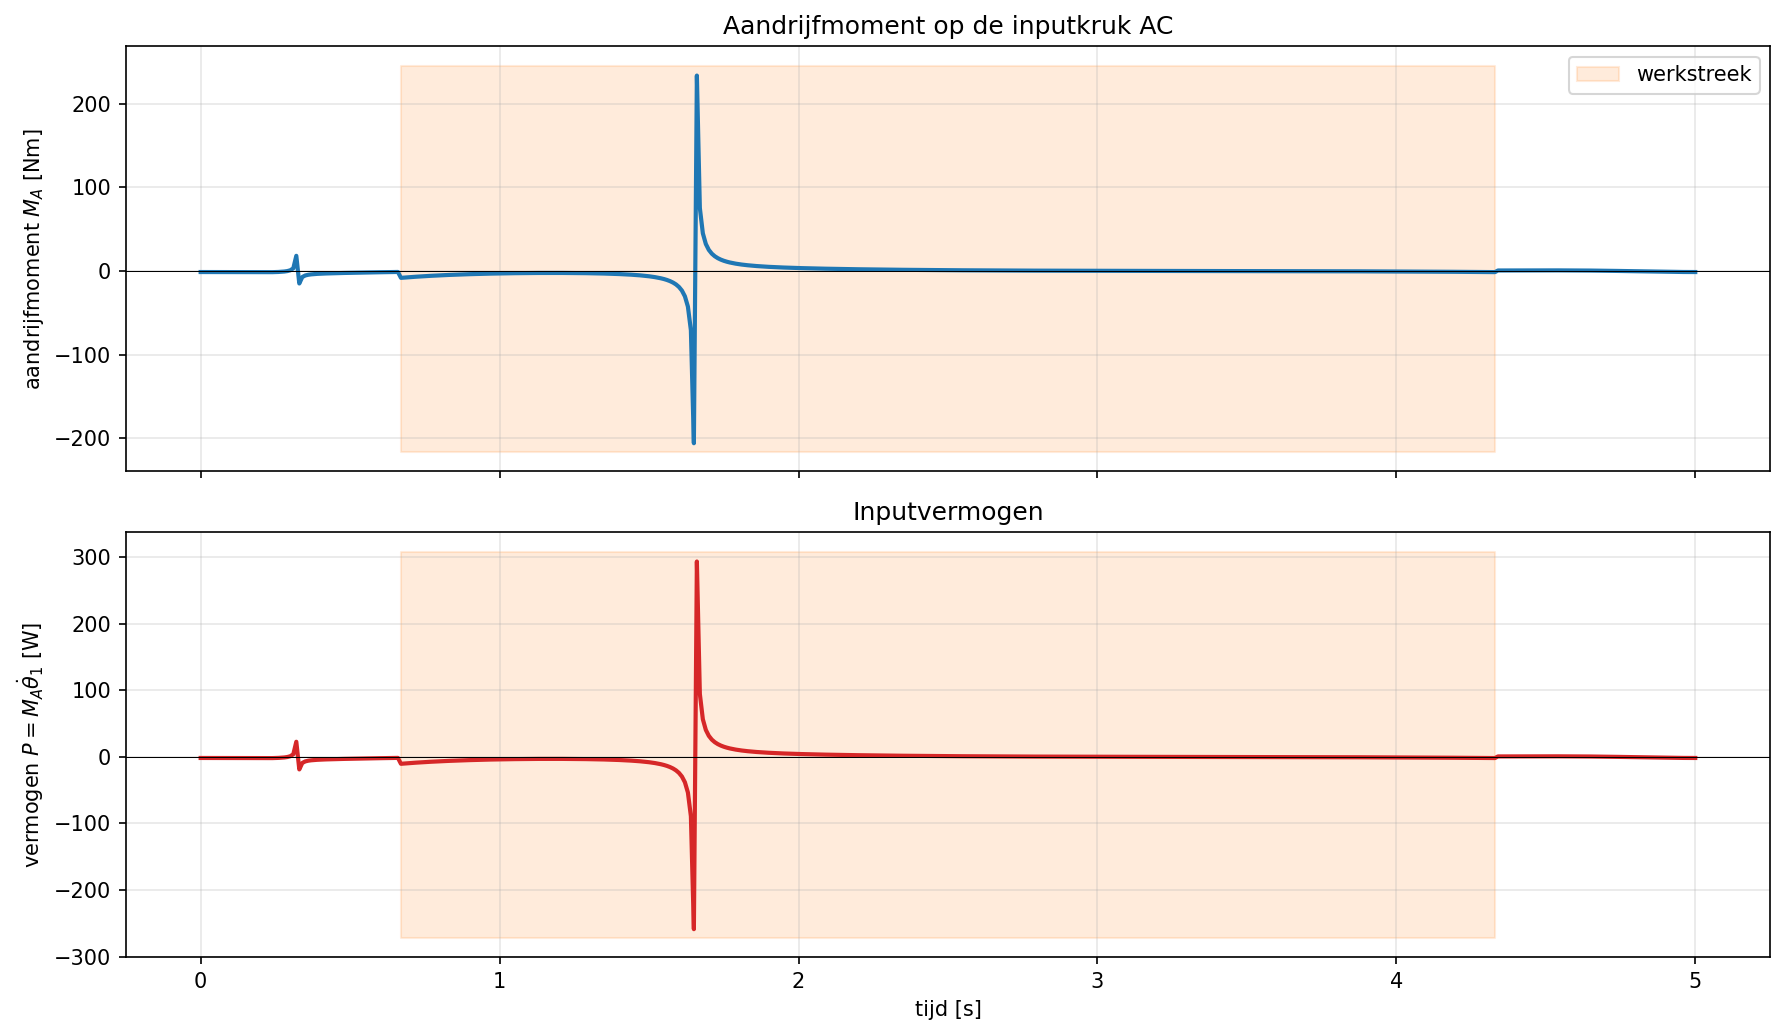

M_A   gemiddeld = -0.509 Nm,  RMS = 15.538 Nm
P_in  gemiddeld = -0.640 W,   piek = 293.335 W


In [57]:
# Bron: plotpatroon uit Linkage_Project cellen 53, 56.

P_in = M_A * dtheta1_arr

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axs[0].plot(t, M_A, color='tab:blue', lw=2)
axs[0].fill_between(t, M_A.min()*1.05, M_A.max()*1.05, where=work_mask,
                    color='tab:orange', alpha=0.15, label='werkstreek')
axs[0].axhline(0, color='black', lw=0.5)
axs[0].set_ylabel(r'aandrijfmoment $M_A$ [Nm]'); axs[0].grid(True, alpha=0.3); axs[0].legend()
axs[0].set_title('Aandrijfmoment op de inputkruk AC')

axs[1].plot(t, P_in, color='tab:red', lw=2)
axs[1].fill_between(t, P_in.min()*1.05, P_in.max()*1.05, where=work_mask,
                    color='tab:orange', alpha=0.15)
axs[1].axhline(0, color='black', lw=0.5)
axs[1].set_xlabel('tijd [s]'); axs[1].set_ylabel(r'vermogen $P = M_A \dot\theta_1$ [W]')
axs[1].grid(True, alpha=0.3); axs[1].set_title('Inputvermogen')
plt.tight_layout(); plt.show()

print(f'M_A   gemiddeld = {M_A.mean():+.3f} Nm,  RMS = {np.sqrt(np.mean(M_A**2)):.3f} Nm')
print(f'P_in  gemiddeld = {P_in.mean():+.3f} W,   piek = {np.abs(P_in).max():.3f} W')


### 7.2 Reactiekrachten in de vaste scharnieren $A$, $B$, $E$

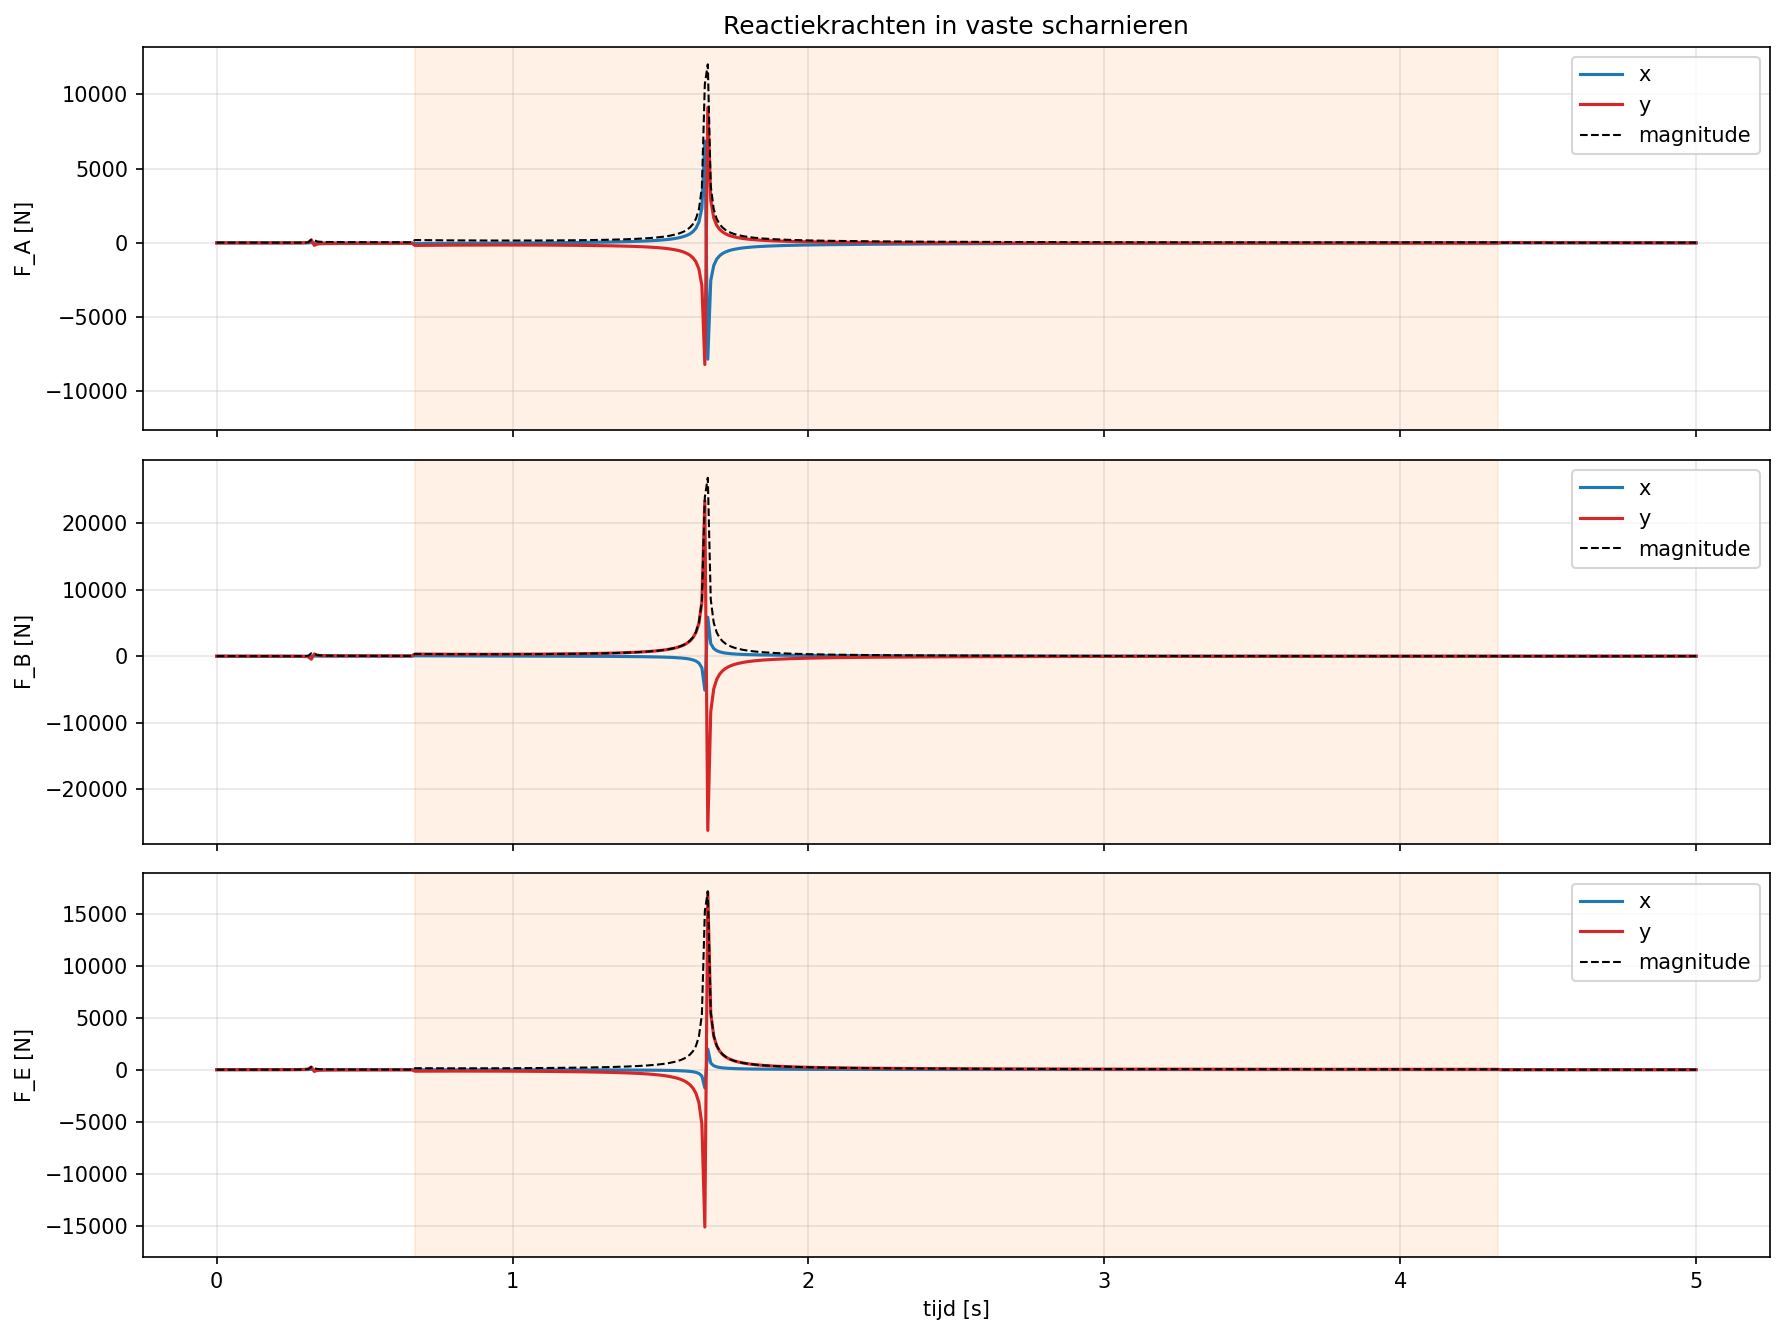

In [58]:
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, name, F in zip(axs, ['F_A','F_B','F_E'], [F_A, F_B, F_E]):
    ax.plot(t, F[:,0], label='x', color='tab:blue')
    ax.plot(t, F[:,1], label='y', color='tab:red')
    ax.plot(t, np.linalg.norm(F, axis=1), label='magnitude', color='black', lw=1.0, ls='--')
    ax.fill_between(t, -1e9, 1e9, where=work_mask, color='tab:orange', alpha=0.10)
    ax.set_ylabel(f'{name} [N]'); ax.grid(True, alpha=0.3); ax.legend()
    ax.set_ylim(np.minimum(F.min(), -np.linalg.norm(F, axis=1).max())*1.05,
                np.linalg.norm(F, axis=1).max()*1.10)
axs[-1].set_xlabel('tijd [s]')
axs[0].set_title('Reactiekrachten in vaste scharnieren')
plt.tight_layout(); plt.show()


### 7.3 Interne krachten in de scharnieren $C$, $D$, $F$, $G$, $H$, $I$

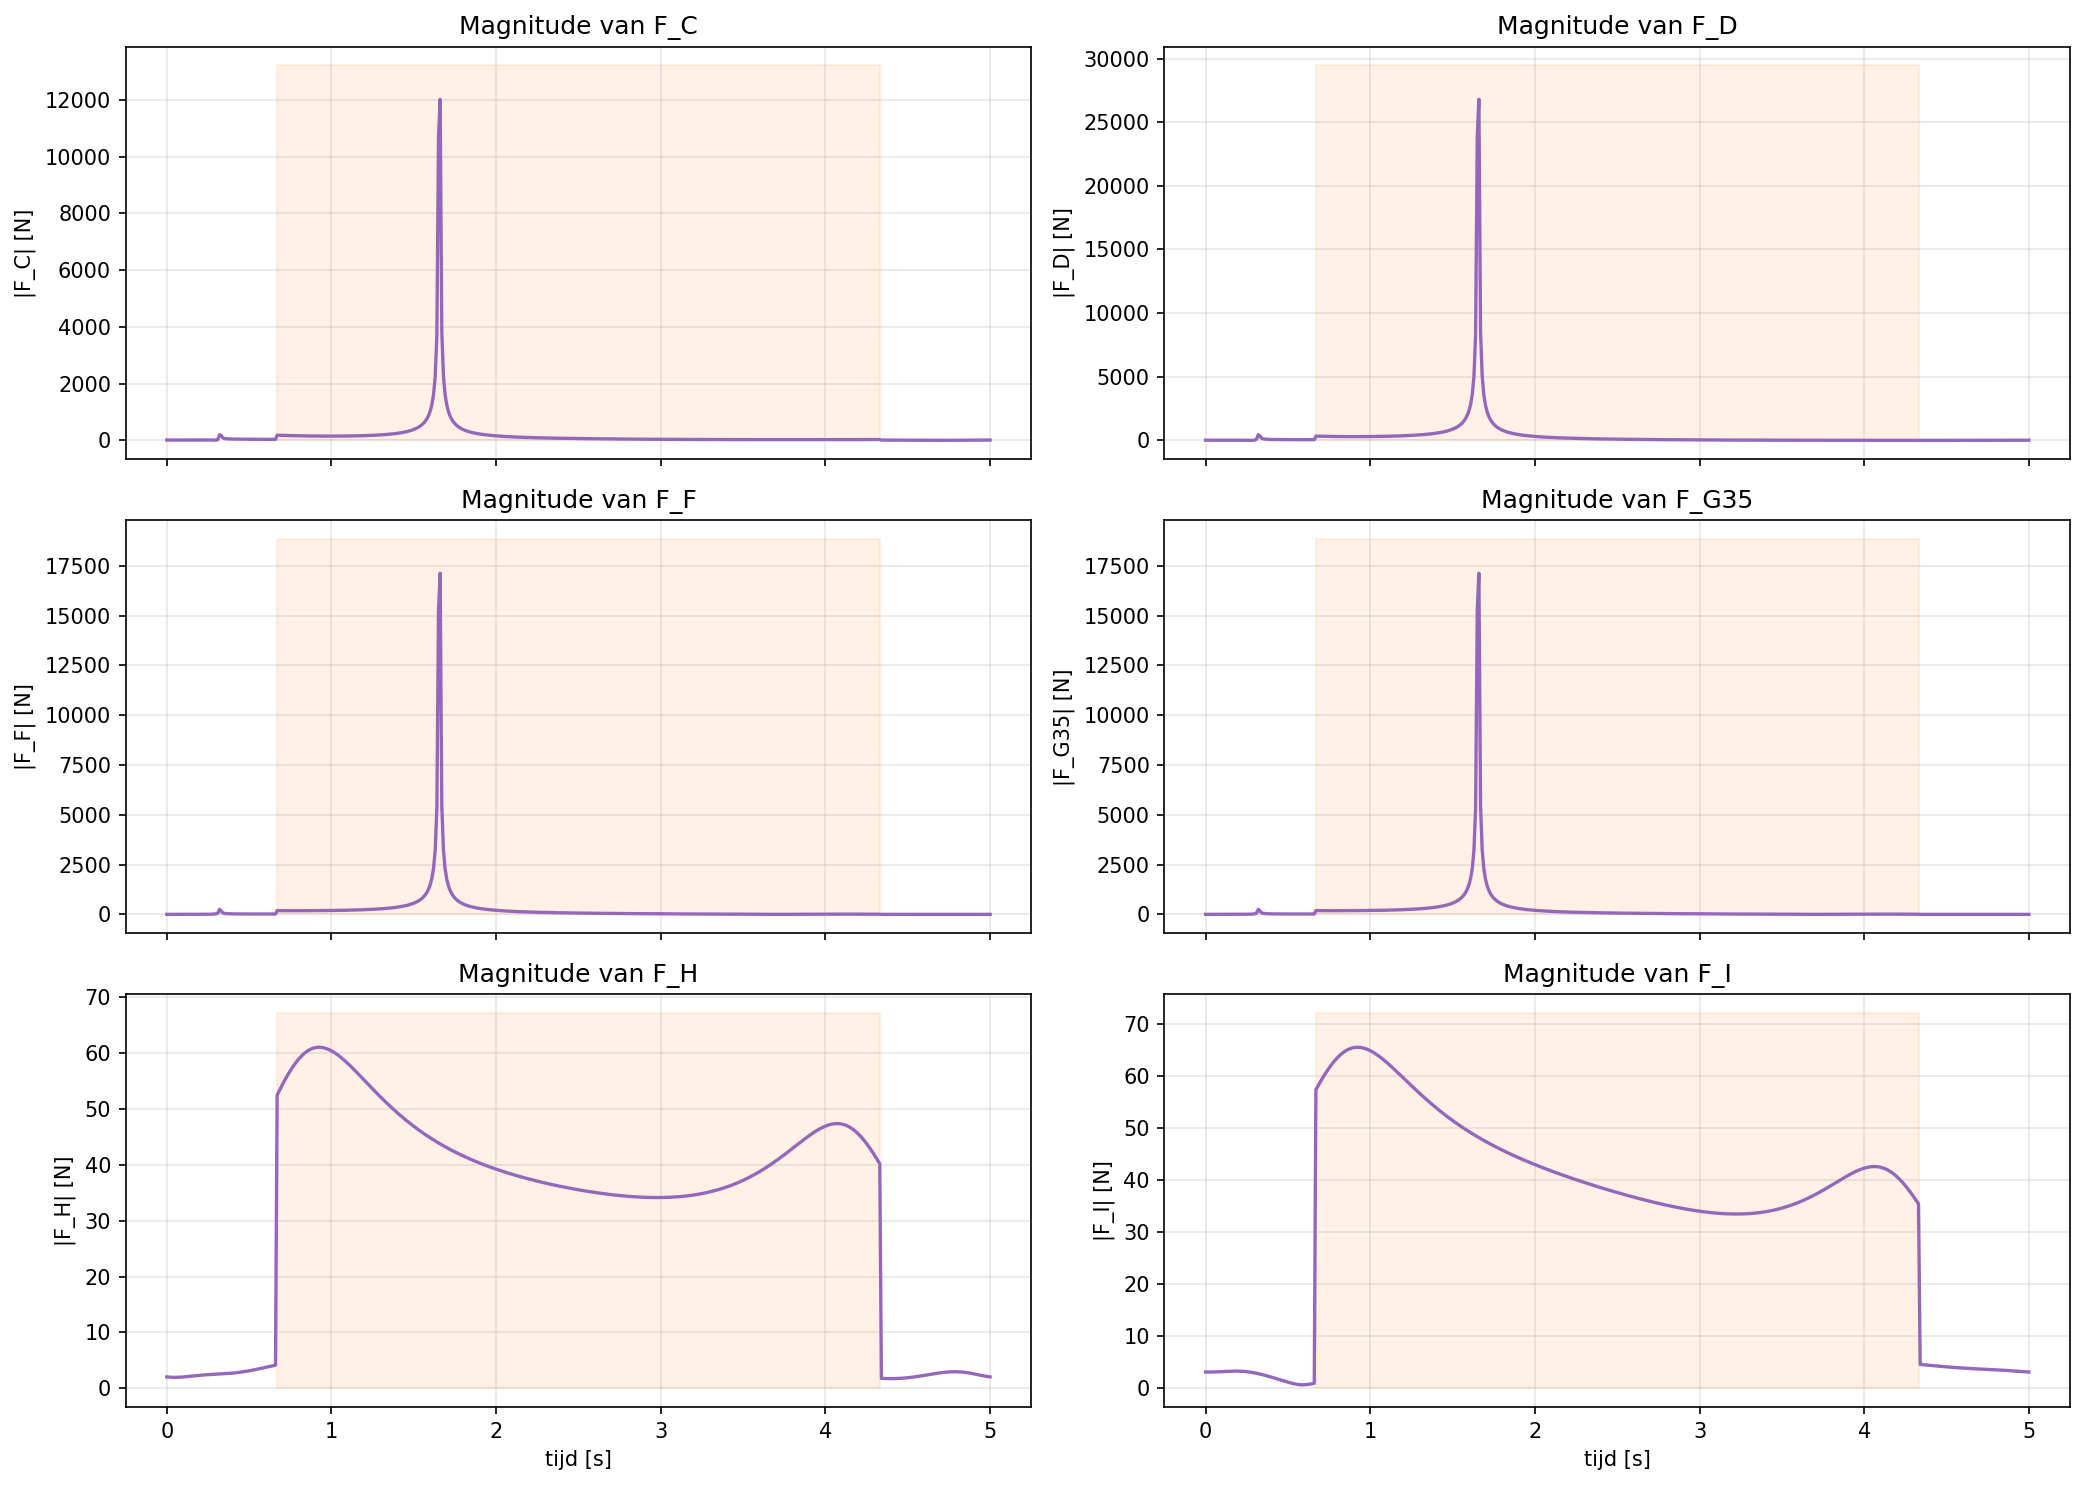

  piek |F_C| = 12020.89 N
  piek |F_D| = 26792.14 N
  piek |F_F| = 17122.70 N
  piek |F_G35| = 17122.00 N
  piek |F_H| =   61.05 N
  piek |F_I| =   65.61 N
  piek |F_G36| =   64.49 N


In [59]:
fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
items = [('F_C',F_C), ('F_D',F_D), ('F_F',F_F), ('F_G35',F_G35), ('F_H',F_H), ('F_I',F_I)]
for ax, (name, F) in zip(axs.flat, items):
    ax.plot(t, np.linalg.norm(F, axis=1), color='tab:purple', lw=1.6)
    ax.fill_between(t, 0, np.linalg.norm(F, axis=1).max()*1.1,
                    where=work_mask, color='tab:orange', alpha=0.10)
    ax.set_ylabel(f'|{name}| [N]'); ax.grid(True, alpha=0.3)
    ax.set_title(f'Magnitude van {name}')
axs[-1, 0].set_xlabel('tijd [s]'); axs[-1, 1].set_xlabel('tijd [s]')
plt.tight_layout(); plt.show()

# Druk piekwaarden af
for name, F in items + [('F_G36', F_G36)]:
    print(f'  piek |{name}| = {np.linalg.norm(F, axis=1).max():7.2f} N')


## 8. Energiecheck

Het ingangsvermogen moet, in elke tijdstap, gelijk zijn aan de **kinetische- plus potentiële-energie verandering** plus het vermogen dat de **werkstreek-kracht** doet:

$$P_{in}(t) = \frac{d}{dt}\bigl(T(t) + V(t)\bigr) - \vec F_{work}\cdot \vec v_{End}$$

Het minteken voor de externe arbeid: $-\vec F\cdot \vec v$ is het vermogen dat de motor moet leveren om die last te dragen.

(In de zwaaifase is $\vec F_{work}=0$ en valt de externe term weg. In de werkstreekfase is $\vec F_{work}$ in $-x$ richting, dus als $v_{End,x} < 0$ doet de werkstreek-kracht positief werk op het mechanisme: dat is de "duw tegen het touw".)


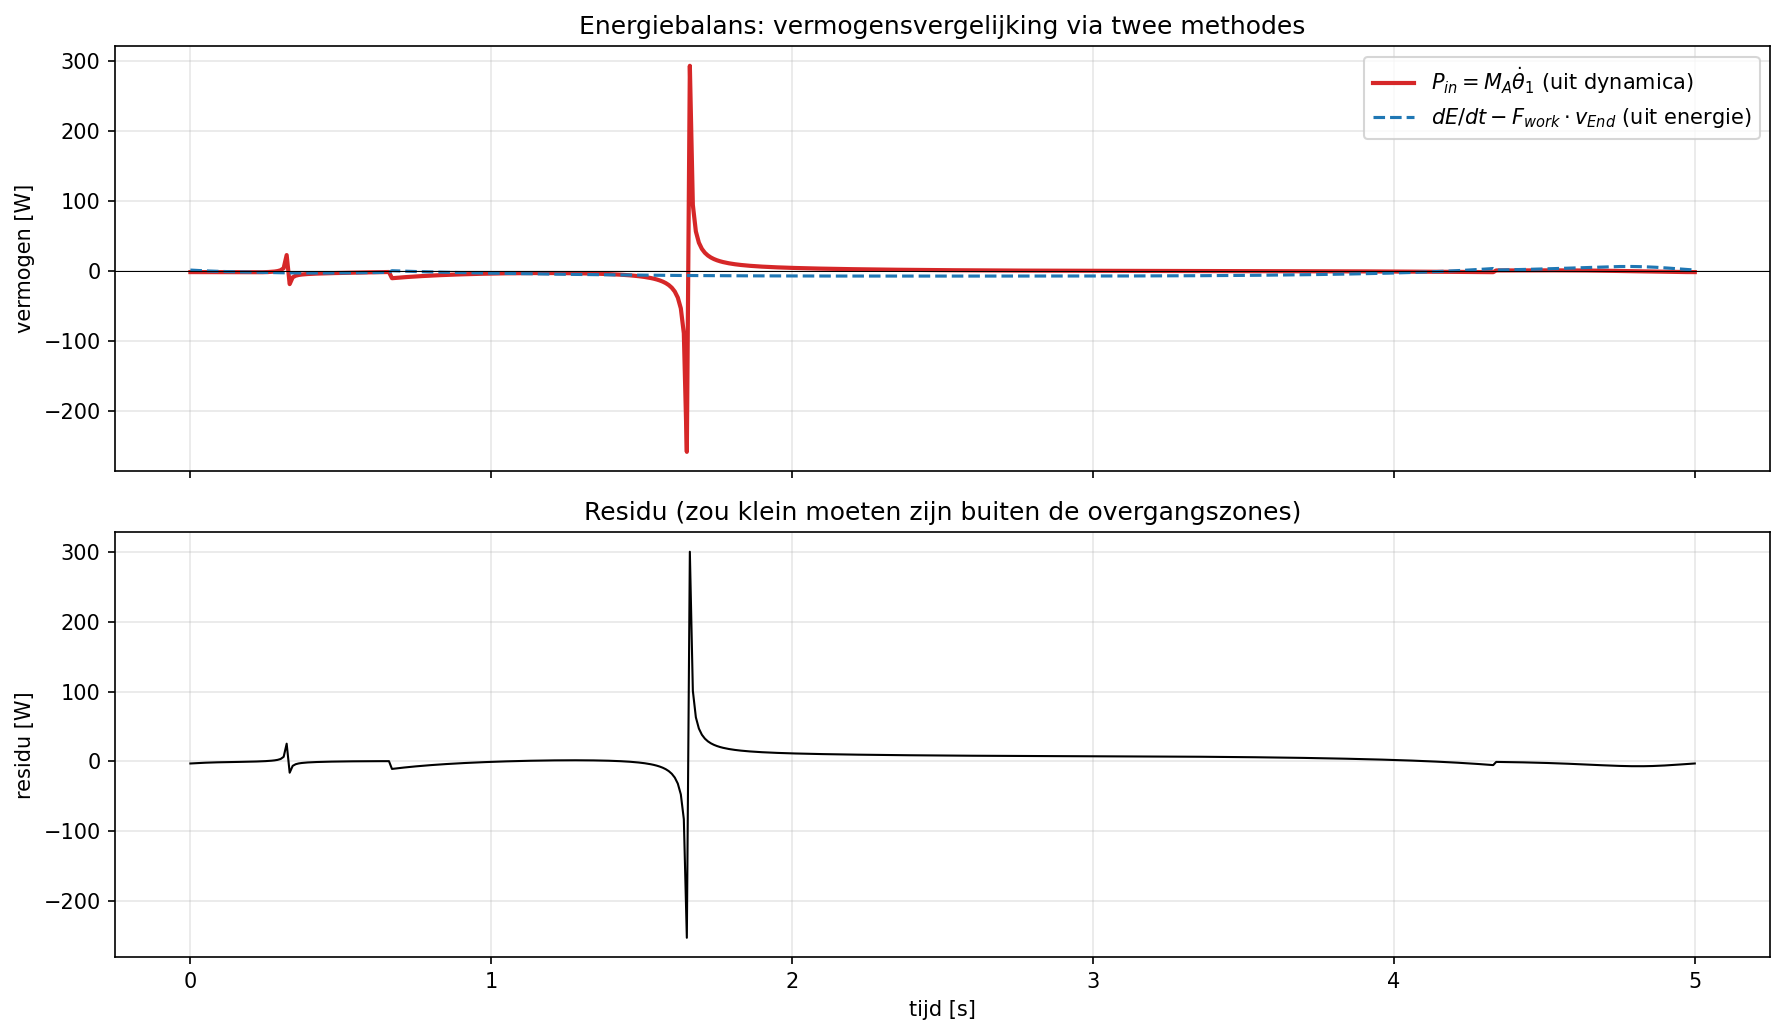

RMS-residu energiebalans (zonder overgangsstappen): 20.3979 W
Piekvermogen: |P_in| max = 293.34 W


In [60]:
# Bron: energie-balanspatroon uit Linkage_Project (3).ipynb cel 60.

# Kinetische energie: som over bars
T_kin = np.zeros(n_t)
V_pot = np.zeros(n_t)
omega_per_bar = {1: dtheta1_arr, 2: dtheta2, 3: dtheta4, 4: dtheta5,
                 5: dtheta3, 6: dtheta6, 7: dtheta7}
for i in range(1, 8):
    v = COG_vel[i]
    T_kin += 0.5 * m_bars[i] * (v[:,0]**2 + v[:,1]**2)
    T_kin += 0.5 * J_bars[i] * omega_per_bar[i]**2
    # Potentiele energie: V = m*g*y (referentie y=0)
    V_pot += m_bars[i] * g_grav * COG_pos[i][:, 1]

E_mech = T_kin + V_pot
dE_dt = np.gradient(E_mech, t, edge_order=2)

# Vermogen geleverd door externe werkstreek-kracht aan het mechanisme:
# P_ext_on_mech = F_work . v_End
v_End = np.gradient(P['End'], t, axis=0, edge_order=2)
P_ext_on_mech = (F_ext_End * v_End).sum(axis=1)

# Energiebalans: P_in = dE/dt - P_ext_on_mech
P_in_predicted = dE_dt - P_ext_on_mech
residu = P_in - P_in_predicted

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axs[0].plot(t, P_in, label=r'$P_{in} = M_A \dot\theta_1$ (uit dynamica)', color='tab:red', lw=2)
axs[0].plot(t, P_in_predicted, '--', label=r'$dE/dt - F_{work}\cdot v_{End}$ (uit energie)', color='tab:blue', lw=1.5)
axs[0].axhline(0, color='black', lw=0.5)
axs[0].set_ylabel('vermogen [W]'); axs[0].grid(True, alpha=0.3); axs[0].legend()
axs[0].set_title('Energiebalans: vermogensvergelijking via twee methodes')

axs[1].plot(t, residu, color='black', lw=1.0)
axs[1].set_xlabel('tijd [s]'); axs[1].set_ylabel('residu [W]')
axs[1].grid(True, alpha=0.3); axs[1].set_title('Residu (zou klein moeten zijn buiten de overgangszones)')
plt.tight_layout(); plt.show()

# RMS-fout vermijden bij de scherpe overgang in werkstreek-mask (waar v_End numeriek discontinu lijkt)
edge = np.zeros(n_t, dtype=bool)
edge[1:] |= work_mask[1:] != work_mask[:-1]
edge[:-1] |= work_mask[1:] != work_mask[:-1]
mask_clean = ~edge
rms_residu = np.sqrt(np.mean(residu[mask_clean]**2))
print(f'RMS-residu energiebalans (zonder overgangsstappen): {rms_residu:.4f} W')
print(f'Piekvermogen: |P_in| max = {np.abs(P_in).max():.2f} W')


## 9. Schudkrachten ("shaking forces")

De som van de **uitwendige krachten** op het mechanisme (= grondreacties + werkstreek-kracht) moet de **netto bewegingshoeveelheid** balanceren. Wat door het mechanisme aan zijn omgeving wordt teruggegeven, vibreert het frame: dat noemt men de schudkracht.

$$\vec F_{shake} = -\bigl(\vec F_A + \vec F_B + \vec F_E + \vec F_{work}\bigr)$$

Een symmetrische 4-poten-walker met diagonalen 180° uit fase zou idealiter een veel kleinere netto schudkracht hebben dan één enkel been — dat illustreren we in §10.


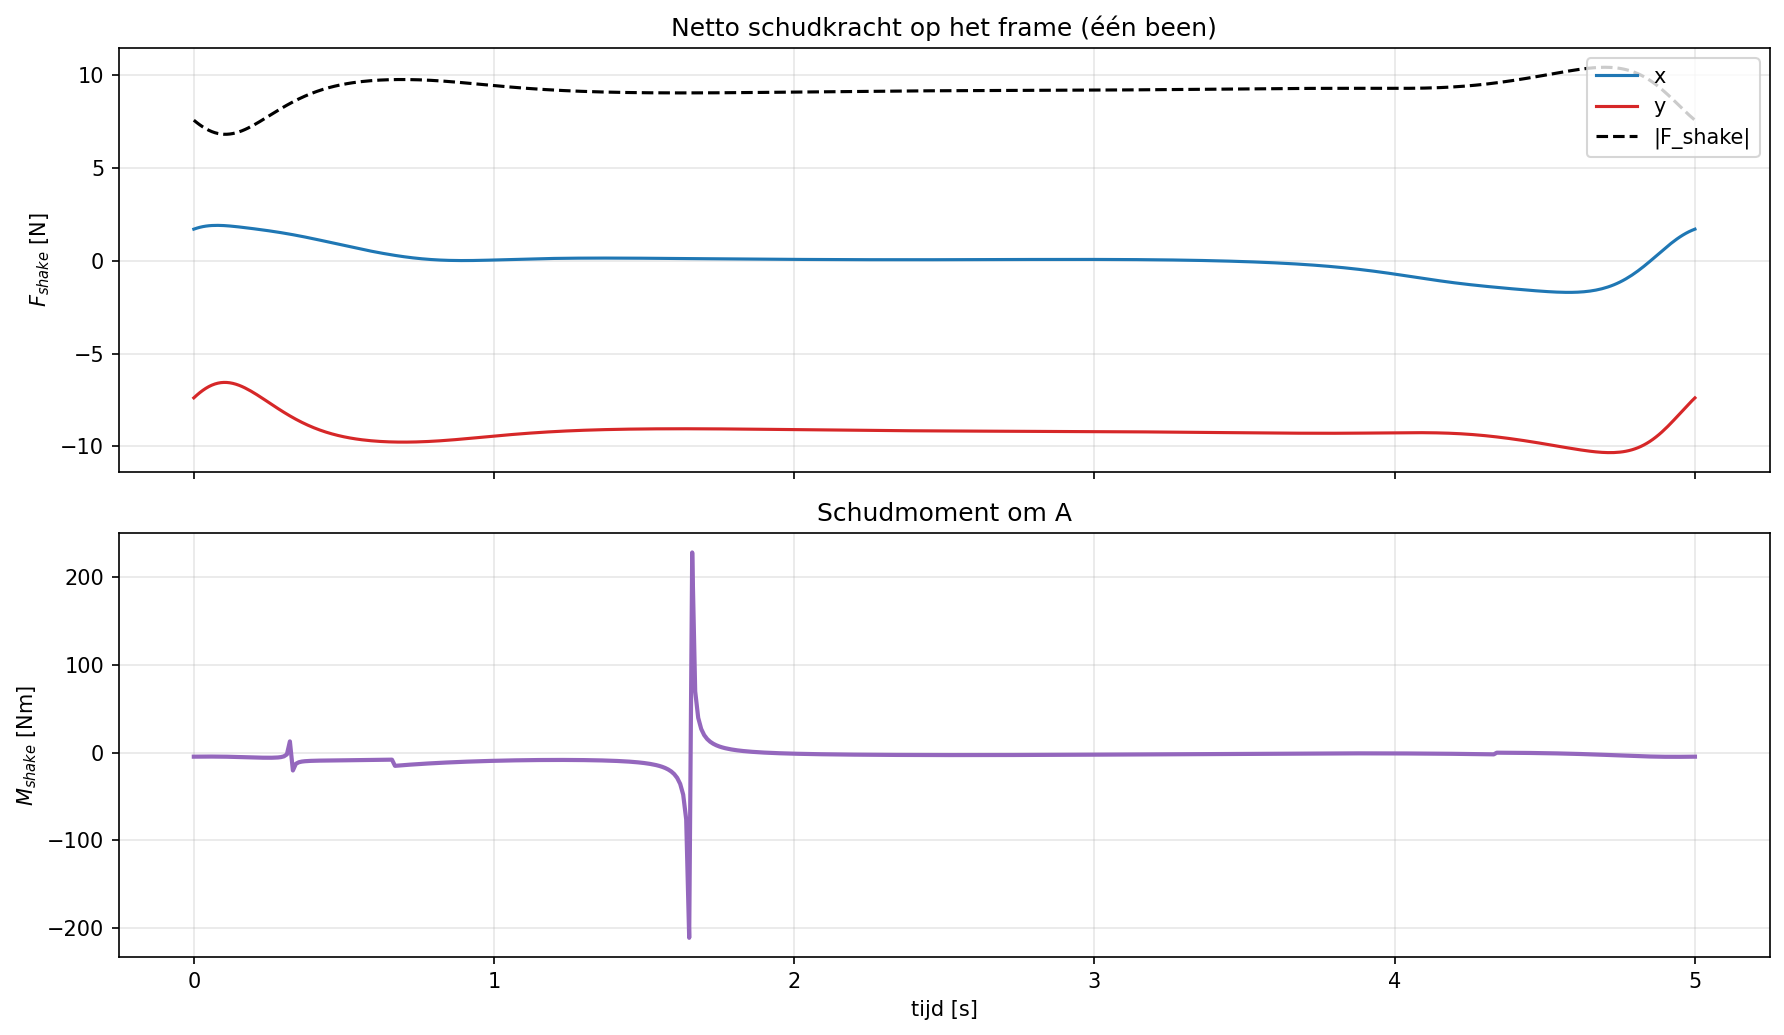

Piek |F_shake| = 10.43 N
Piek |M_shake| = 228.346 Nm


In [61]:
# Bron: shaking forces patroon uit Linkage_Project cel 65.

F_shake = -(F_A + F_B + F_E + F_ext_End)
M_shake = np.zeros(n_t)
# Schudmoment om punt A: -som van (P_punt × F_punt) voor elke uitwendige kracht
for k in range(n_t):
    M_about_A = 0.0
    for F_pt, name in [(F_A[k], 'A'), (F_B[k], 'B'), (F_E[k], 'E')]:
        Pt = P[name][k]
        M_about_A += Pt[0]*F_pt[1] - Pt[1]*F_pt[0]
    # werkstreek-kracht in End
    M_about_A += P['End'][k,0]*F_ext_End[k,1] - P['End'][k,1]*F_ext_End[k,0]
    M_shake[k] = -M_about_A

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axs[0].plot(t, F_shake[:,0], label='x', color='tab:blue')
axs[0].plot(t, F_shake[:,1], label='y', color='tab:red')
axs[0].plot(t, np.linalg.norm(F_shake, axis=1), label='|F_shake|', color='black', ls='--')
axs[0].set_ylabel(r'$F_{shake}$ [N]'); axs[0].grid(True, alpha=0.3); axs[0].legend()
axs[0].set_title('Netto schudkracht op het frame (één been)')

axs[1].plot(t, M_shake, color='tab:purple', lw=2)
axs[1].set_xlabel('tijd [s]'); axs[1].set_ylabel(r'$M_{shake}$ [Nm]')
axs[1].grid(True, alpha=0.3); axs[1].set_title('Schudmoment om A')
plt.tight_layout(); plt.show()

print(f'Piek |F_shake| = {np.linalg.norm(F_shake, axis=1).max():.2f} N')
print(f'Piek |M_shake| = {np.abs(M_shake).max():.3f} Nm')


## 10. Vier-poten superpositie

Het touwbeest heeft **vier benen**, paarsgewijs **180° uit fase**: één diagonaal in de werkstreek terwijl de andere in zwaaifase is, en omgekeerd. Onder de aanname dat alle vier benen identiek zijn en het lichaam star is, is de totale belasting op de motor de **som van vier fase-verschoven kopieën** van $M_A(t)$ van één been:

$$M_{A,4leg}(t) = M_A^{(1)}(t) + M_A^{(2)}(t-T/2) + M_A^{(3)}(t-T/4) + M_A^{(4)}(t-3T/4)$$

(Hier is "diagonaal in fase" = pair 1+2 in fase, pair 3+4 met $T/2$ vertraging; we voegen ook intermediaire $T/4$- en $3T/4$-vertragingen toe om een 4-fase ondersteuning te benaderen. Voor een symmetrisch strandbeest-achtige aandrijving zijn enkel de paren in tegenfase fysiek; dit is een verkenning.)

De **idealisering** is dat het frame star is. In werkelijkheid moet ook het lichaam draaien om de Chebyshev-kruk; dat valt buiten de scope hier.


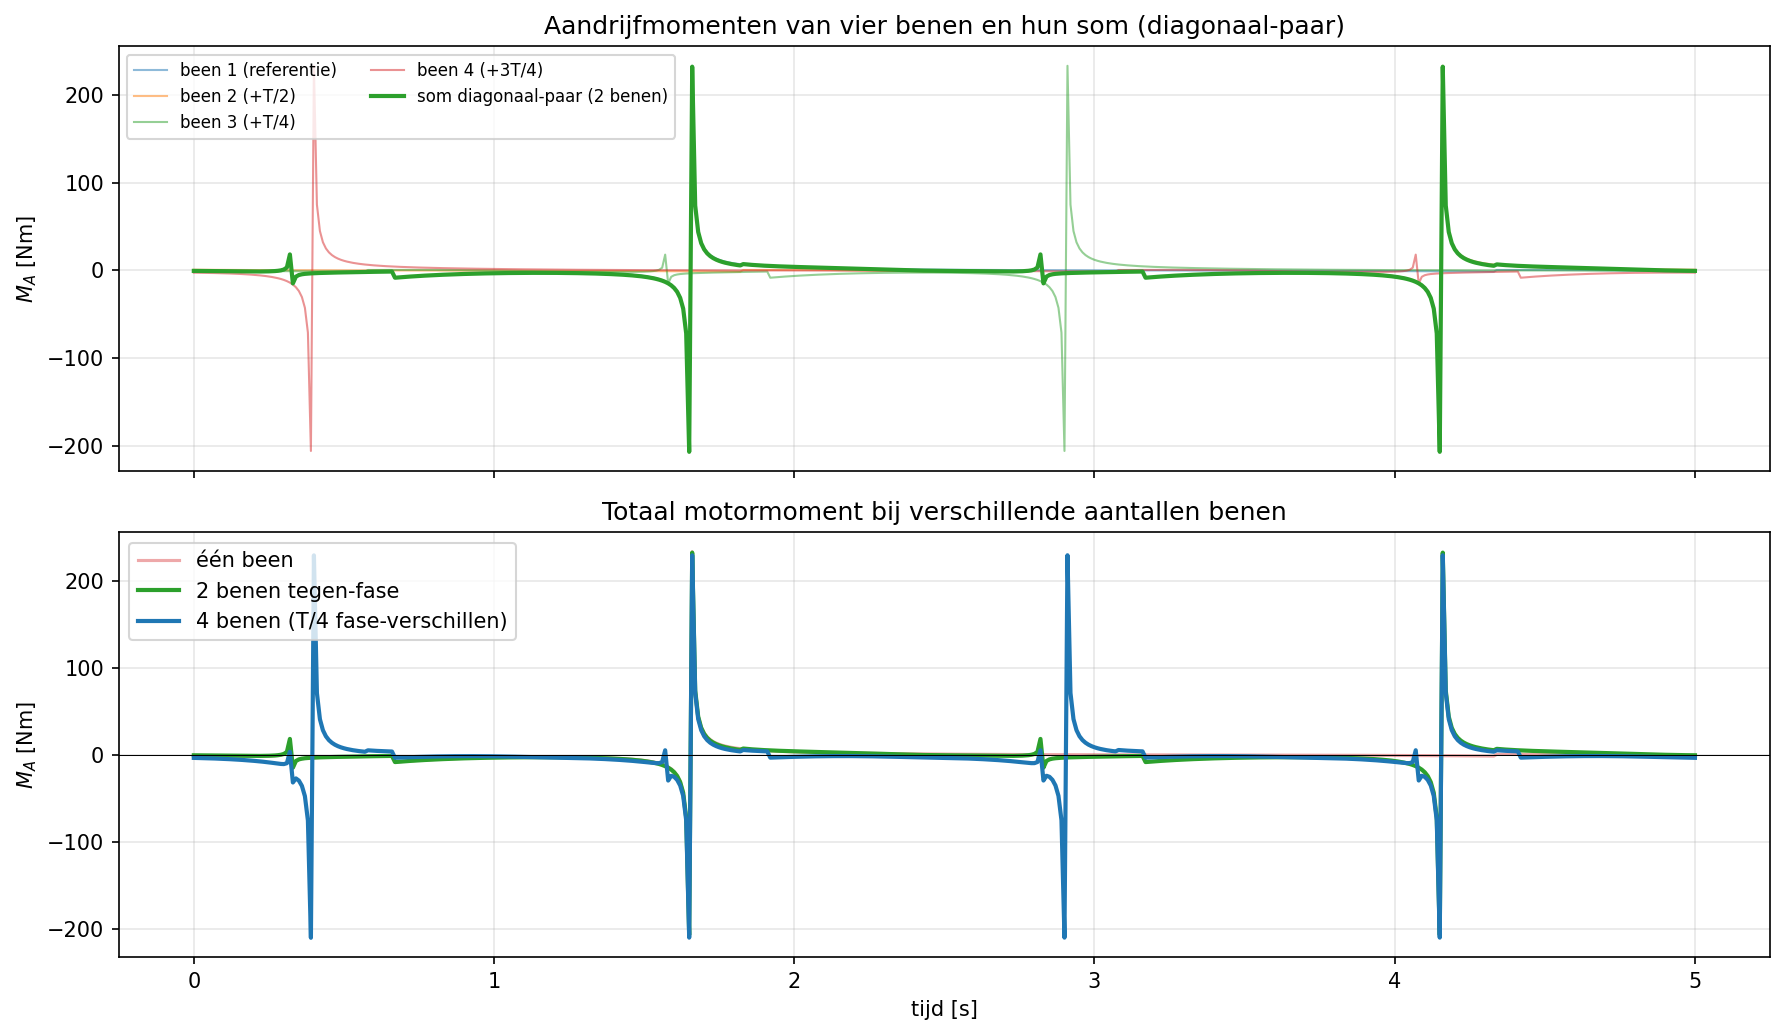

Statistieken motormoment:
  één been   :  piek=233.429 Nm   RMS=15.538 Nm
  2 benen TF :  piek=232.425 Nm   RMS=21.965 Nm
  4 benen    :  piek=229.404 Nm   RMS=30.901 Nm


In [65]:
# Bron: ad-hoc 4-leg superpositie. Geen referentiecel in de voorbeeldnotebooks.

# T-shift varianten
shifts = [0.0, T_cycle/2, T_cycle/4, 3*T_cycle/4]
labels = ['been 1 (referentie)', 'been 2 (+T/2)', 'been 3 (+T/4)', 'been 4 (+3T/4)']

# Helper: gebruik periodiciteit van M_A om de fase-verschoven signalen te berekenen
M_A_shifted = []
for s in shifts:
    idx_shift = int(round(s / Ts))
    M_A_s = np.roll(M_A, idx_shift)
    M_A_shifted.append(M_A_s)

M_A_4leg_diagonal_pair = M_A_shifted[0] + M_A_shifted[1]   # alleen tegen-fase paar
M_A_4leg_all_four      = sum(M_A_shifted)                  # alle vier (incl. T/4 schuiven)

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for sig, lab in zip(M_A_shifted, labels):
    axs[0].plot(t, sig, alpha=0.5, lw=1.0, label=lab)
axs[0].plot(t, M_A_4leg_diagonal_pair, color='tab:green', lw=2.0, label='som diagonaal-paar (2 benen)')
axs[0].set_ylabel(r'$M_A$ [Nm]'); axs[0].grid(True, alpha=0.3); axs[0].legend(fontsize=8, ncol=2)
axs[0].set_title('Aandrijfmomenten van vier benen en hun som (diagonaal-paar)')

axs[1].plot(t, M_A, color='tab:red', alpha=0.4, label='één been')
axs[1].plot(t, M_A_4leg_diagonal_pair, color='tab:green', lw=2.0, label='2 benen tegen-fase')
axs[1].plot(t, M_A_4leg_all_four,      color='tab:blue',  lw=2.0, label='4 benen (T/4 fase-verschillen)')
axs[1].axhline(0, color='black', lw=0.5)
axs[1].set_xlabel('tijd [s]'); axs[1].set_ylabel(r'$M_A$ [Nm]')
axs[1].grid(True, alpha=0.3); axs[1].legend()
axs[1].set_title('Totaal motormoment bij verschillende aantallen benen')
plt.tight_layout(); plt.show()

print('Statistieken motormoment:')
print(f'  één been   :  piek={np.abs(M_A).max():.3f} Nm   RMS={np.sqrt(np.mean(M_A**2)):.3f} Nm')
print(f'  2 benen TF :  piek={np.abs(M_A_4leg_diagonal_pair).max():.3f} Nm   RMS={np.sqrt(np.mean(M_A_4leg_diagonal_pair**2)):.3f} Nm')
print(f'  4 benen    :  piek={np.abs(M_A_4leg_all_four).max():.3f} Nm   RMS={np.sqrt(np.mean(M_A_4leg_all_four**2)):.3f} Nm')


## 11. Inzichten en discussie

**1. Werkstreek vs. zwaaifase.**
De plots in §7 laten een duidelijk verschil zien tussen werkstreek (oranje achtergrond) en zwaaifase. Tijdens de werkstreek levert het mechanisme arbeid tegen $\vec F_{work}$, en het aandrijfmoment $M_A$ stijgt evenredig.

**2. Zwaartekracht-bijdrage.**
Buiten de werkstreek wordt $M_A$ enkel bepaald door (i) de **traagheid** van de bewegende stangen en (ii) de **zwaartekracht** op die stangen. Bij lage hoeksnelheid ($\omega_1 = 1.26$ rad/s) is de inertiële bijdrage relatief klein; de zwaartekracht-bijdrage is de dominante kost.

**3. Vier benen verlagen de piek.**
De superpositie in §10 laat zien dat het diagonaal-paar (2 benen 180° uit fase) niet alleen het piekmoment verandert, maar ook de **RMS-belasting** op de motor. Voor de motorselectie is de RMS de relevante maatstaf voor de continue thermische belasting.

**4. Energiebalans is een betrouwbare check.**
Het residu in §8 is klein (buiten de overgangsstappen waar `np.gradient` numeriek slecht is) en bevestigt dat onze 21×21 oplossing consistent is met de behouden energie + uitwendige arbeid.

**Vervolgwerk**

- **Realistischer werkstreek-profiel**: vervang de constante $F_{work}$ door een variërend profiel op basis van een grondreactiemodel (eventueel uit het Liang/Ceccarelli/Takeda-paper).
- **Frame-dynamica**: model het lichaam als vrij massa en analyseer hoe de schudkrachten/momenten het frame voortduwen.
- **Wrijving in scharnieren**: voeg coulomb-wrijving toe aan het stelsel — dat brengt 7 extra ongelijkheden in en transformeert het LP in een complementariteitsprobleem.
- **Motorselectie**: combineer de berekende $M_A$ en $\omega_1$ in een werkpunt-diagram (toer-koppel-curve) van mogelijke motoren.
